# Tech Challenge - Fase 1: Análise Exploratória e Preparação de Dados
**Objetivo:** Este notebook tem como finalidade carregar a base de dados do e-commerce, realizar o tratamento inicial das variáveis (Feature Engineering), garantir a ausência de *Data Leakage* (Fuga de Dados) e explorar os padrões operacionais que mais afetam o NPS.

In [1]:
# Importando as bibliotecas essenciais para a manipulação e visualização de dados
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Ignorando avisos para manter a saída do notebook limpa
warnings.filterwarnings('ignore')

## 1. Carregamento e Visão Geral da Base de Dados
Vamos importar os dados originais e entender a sua estrutura (tipos de dados, quantidade de registros e presença de valores nulos).

In [2]:
# Carregando o dataset
df = pd.read_csv('desafio_nps_fase_1.csv')

# Exibindo informações estruturais e as primeiras linhas
display(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

None

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


## 2. Engenharia de Variáveis e Prevenção de Data Leakage
Para que nossa análise e futuro modelo preditivo façam sentido no ambiente de negócios, precisamos de duas ações críticas:
1. **Criar a Variável Alvo (`nps_class`):** O problema de negócio exige que prevejamos a categoria do cliente (Detrator, Neutro ou Promotor) e não apenas a sua nota exata.
2. **Evitar Fuga de Dados:** Variáveis de pós-venda, como o número de reclamações (`complaints_count`) ou a nota interna de CSAT (`csat_internal_score`), só existem *após* a jornada do cliente terminar. Elas serão removidas para garantir que a nossa análise reflita o momento exato em que a empresa precisa tomar a decisão preventiva.

In [3]:
# 1. Função para categorizar o NPS segundo a metodologia global
def classificar_nps(nota):
    if nota <= 6:
        return 'Detrator'
    elif nota <= 8:
        return 'Neutro'
    else:
        return 'Promotor'

# Aplicando a regra e criando a coluna alvo
df['nps_class'] = df['nps_score'].apply(classificar_nps)

# 2. Removendo variáveis preditivas "do futuro" para evitar Data Leakage
colunas_vazamento = ['complaints_count', 'csat_internal_score']
df = df.drop(columns=colunas_vazamento, errors='ignore')

# Verificando a distribuição do nosso alvo
print("--- DISTRIBUIÇÃO DO NPS ---")
print(df['nps_class'].value_counts(normalize=True) * 100)

--- DISTRIBUIÇÃO DO NPS ---
nps_class
Detrator    74.04
Neutro      17.92
Promotor     8.04
Name: proportion, dtype: float64


## 3. Análise Exploratória de Dados (EDA)
Vamos investigar quais fatores operacionais mais impactam o sentimento do consumidor utilizando uma Matriz de Correlação e, em seguida, analisar as médias dos perfis para encontrar "pontos de ruptura".

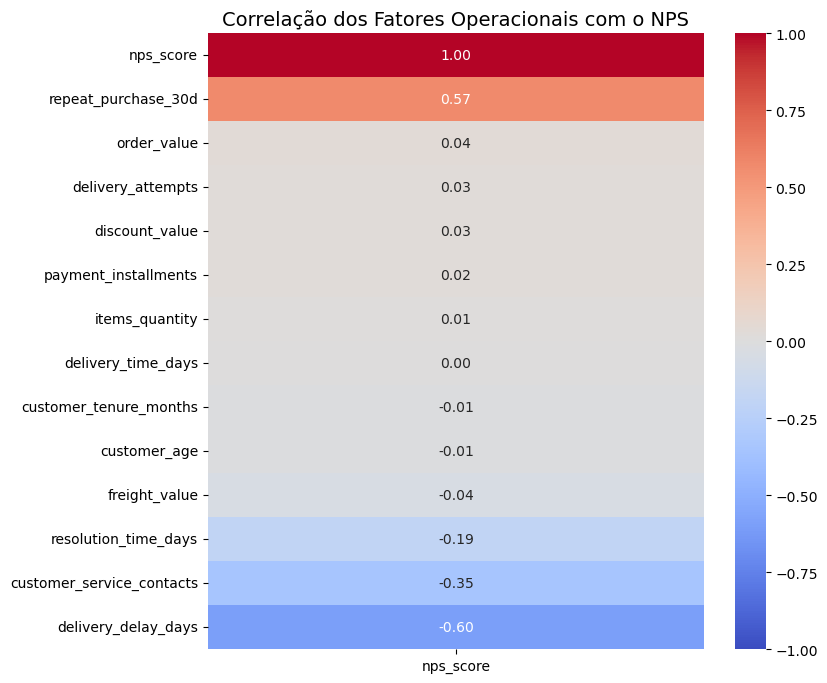


--- MÉDIA DE ATRASOS, CONTATOS E RECOMPRA POR CLASSE ---


,delivery_delay_days,customer_service_contacts,repeat_purchase_30d
nps_class,,,
Promotor,0.76,0.78,1.00
Neutro,1.40,1.13,0.04
Detrator,2.53,1.69,0.00


In [4]:
# Filtrando apenas colunas numéricas, excluindo os IDs
colunas_numericas = df.select_dtypes(include=['int64', 'float64']).columns
colunas_para_correlacao = [col for col in colunas_numericas if col not in ['customer_id', 'order_id']]

# Calculando a correlação com o score de NPS
matriz_corr = df[colunas_para_correlacao].corr()
correlacao_nps = matriz_corr[['nps_score']].sort_values(by='nps_score', ascending=False)

# Plotando o Heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(correlacao_nps, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlação dos Fatores Operacionais com o NPS', fontsize=14)
plt.show()

# Investigando o "Ponto de Ruptura" Logístico e de Atendimento
ruptura_df = df.groupby('nps_class')[['delivery_delay_days', 'customer_service_contacts', 'repeat_purchase_30d']].mean().round(2)
ruptura_df = ruptura_df.reindex(['Promotor', 'Neutro', 'Detrator'])

print("\n--- MÉDIA DE ATRASOS, CONTATOS E RECOMPRA POR CLASSE ---")
display(ruptura_df)

## 4. Exportação dos Dados Limpos
Para garantir um pipeline organizado, exportaremos este dataset limpo para ser utilizado na próxima fase de modelagem preditiva.

In [5]:
# Salvando o dataset pronto para o modelo
df.to_csv('dados_preparados_ml.csv', index=False)
print("Dados exportados com sucesso para 'dados_preparados_ml.csv'.")

Dados exportados com sucesso para 'dados_preparados_ml.csv'.
